In [4]:
from profiling_and_attack import mlp_eshard, information, cnn, cnn_ASCAD, mlp

from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

In [1]:
import tensorflow as tf

def train_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=400)

    return model
def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result

2025-02-22 12:06:56.243829: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-22 12:06:56.466061: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-22 12:06:56.466099: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-22 12:06:56.503493: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-22 12:06:56.578412: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
dataset_id = 'ches_ctf'
resample_window=80
traces_dim = 15000

n_prof= 30000
import gc

lm = "HW"
target_byte = 2
path = "/mnt/d/Datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)
pi_og, pi_patch_new, pi_patch_og = [], [], []
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


Model: "mlp_softmax"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 15000)]           0         
                                                                 
 dense_12 (Dense)            (None, 40)                600040    
                                                                 
 dense_13 (Dense)            (None, 40)                1640      
                                                                 
 dense_14 (Dense)            (None, 40)                1640      
                                                                 
 dense_15 (Dense)            (None, 40)                1640      
                                                                 
 output (Dense)              (None, 9)                 369       
                                                                 
Total params: 605329 (2.31 MB)
Trainable params: 605329

2025-02-22 12:09:47.386038: W external/local_tsl/tsl/framework/bfc_allocator.cc:485] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.68GiB (rounded to 1800000000)requested by op _EagerConst
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-02-22 12:09:47.386088: I external/local_tsl/tsl/framework/bfc_allocator.cc:1039] BFCAllocator dump for GPU_0_bfc
2025-02-22 12:09:47.386102: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (256): 	Total Chunks: 81, Chunks in use: 80. 20.2KiB allocated for chunks. 20.0KiB in use in bin. 5.5KiB client-requested in use in bin.
2025-02-22 12:09:47.386108: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (512): 	Total Chunks: 1, Chunks in use: 0. 512B allocated for chunks. 0B in use in bin. 0B client-requested in use in bin.
2025-02-22 12:09:47.386113: I ext

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

## Training model and plotting PI evolution

In [48]:
import gc

n_epochs = 200
batch_size=400
model = mlp_eshard(9,traces_dim)
training = True
pi_prof, pi_attack = [], []
model_name = f"ches_ctf_byte_{target_byte}"
if not training:
        #Exit if we do now want to train
        raise KeyboardInterrupt
for i in range(n_epochs):
        model.fit(
        x=dataset.x_profiling,
        y=to_categorical(dataset.profiling_labels, num_classes=dataset.classes),
        batch_size=batch_size,
        verbose=2,
        epochs=1,
        shuffle=True)
        model.save_weights(f"model_checkpoints/{model_name}_{(i+1):02d}.weights.h5")
        pi_attack.append(information(model.predict(dataset.x_attack), dataset.attack_labels, dataset.classes))
        pi_prof.append(information(model.predict(dataset.x_profiling[:10000]), dataset.profiling_labels[:10000], dataset.classes))
        print(i, pi_prof[-1], pi_attack[-1])
        gc.collect()

Model: "mlp_softmax"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 15000)]           0         
                                                                 
 dense_20 (Dense)            (None, 40)                600040    
                                                                 
 dense_21 (Dense)            (None, 40)                1640      
                                                                 
 dense_22 (Dense)            (None, 40)                1640      
                                                                 
 dense_23 (Dense)            (None, 40)                1640      
                                                                 
 output (Dense)              (None, 9)                 369       
                                                                 
Total params: 605329 (2.31 MB)
Trainable params: 605329

In [68]:
def reload_model(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    #layer = layers
    model.load_weights(f"model_checkpoints/{model_name}_{epoch:02d}.weights.h5")
    outputs = [model.layers[layer].output for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = new_model.predict(dataset.x_attack).copy()
sbox_ins = (dataset.profiling_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.profiling_keys[:, dataset.target_byte].astype(np.uint8))
probes_for_bit = []

def only_reload(epoch):
    model.load_weights(f"model_checkpoints/{model_name}_{epoch:02d}.weights.h5")


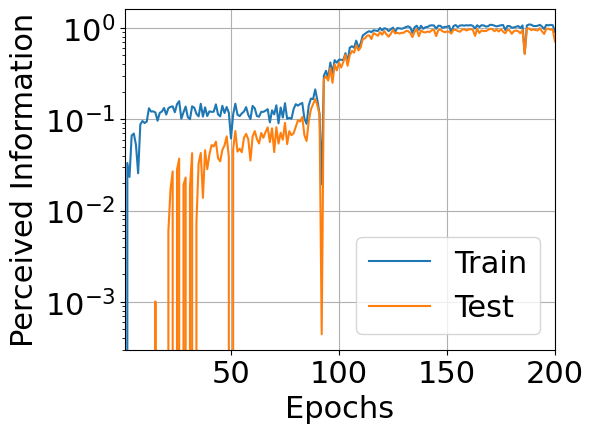

In [51]:
import gc
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
#print(len(pi_attack))
plt.plot(range(1, 201), pi_prof, label="Train")
plt.plot(range(1, 201), pi_attack, label="Test")

plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Perceived Information")
plt.xlim([1, 200])
plt.grid()
plt.legend()
plt.tight_layout()
#plt.savefig("PI_ches.png", dpi=200)
plt.show()


## Logit Visualization

152/152 [==============================] - 0s 1ms/step


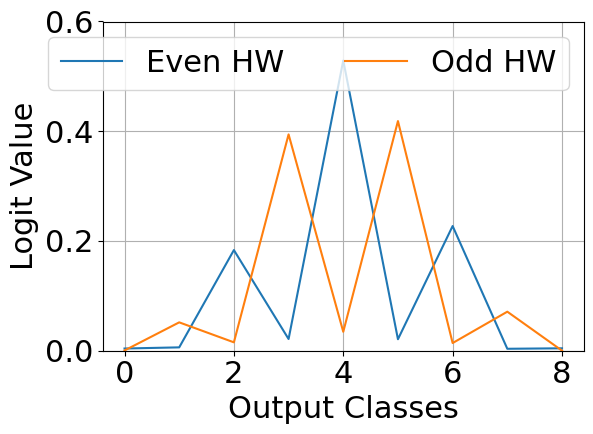

1/1 [==============================] - 0s 12ms/step


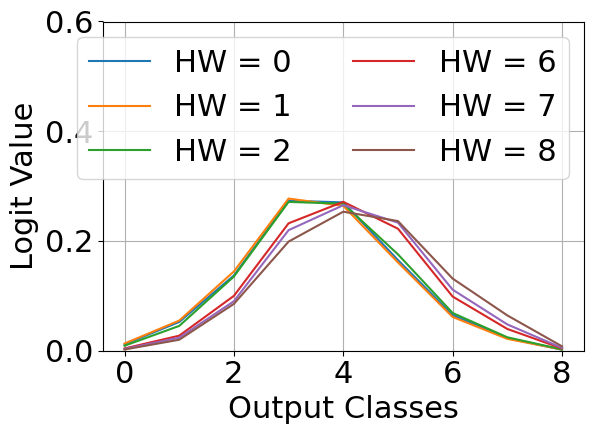

In [63]:
# reload_model(99)
out_logits = []
for i in [0, 1]:
    indices, = np.where(dataset.attack_labels%2 == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"Even HW" if i == 0 else "Odd HW")
plt.ylim([0, 0.6])
plt.grid()
plt.legend(ncol=2, loc=1)
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
plt.tight_layout()
plt.show()
gc.collect()
reload_model(40)
out_logits = []
for i in [0,1,2, 6, 7,8]:
    indices, = np.where(dataset.attack_labels == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
plt.ylim([0, 0.6])
plt.grid()
plt.legend(ncol=2, loc=1)
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
plt.tight_layout()
plt.show()

## PCA stuff


313/313 [==============================] - 0s 1ms/step


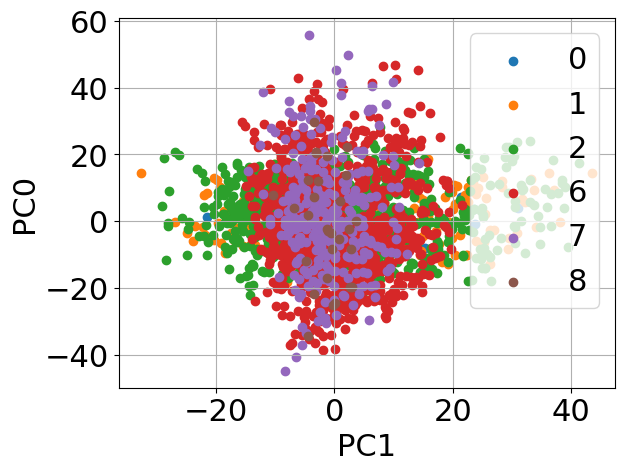

313/313 [==============================] - 0s 1ms/step


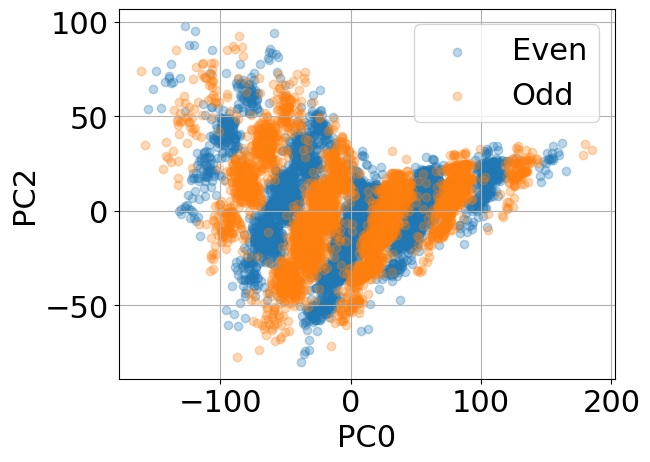

In [92]:
layer = 1
comp_n= 3
from sklearn.decomposition import PCA
gc.collect()
reload_model(45)
new_pca = PCA(n_components=comp_n)

#new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.fit_transform(tmp_att[layer])
in1 = 1
in2 = 0
for i in [0,1,2,6,7,8]:
    indices = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[indices,in1], new_s1_att[indices,in2], label=i)
plt.legend()
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.grid()
plt.show()


comp_n=3
reload_model(150)
new_pca = PCA(n_components=comp_n)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.fit_transform(tmp_att[layer])
in1 = 0
in2 = 2
for i in [0,1]:
    indices = np.where(dataset.attack_labels%2 == i)
    plt.scatter(new_s1_att[indices,in1], new_s1_att[indices,in2], label="Even" if i == 0 else "Odd", alpha=0.3)
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.legend()
plt.grid()
plt.show()

## Activation Patching